# Full-Scale Multistage Mission Example (MissionExecutor API)

This notebook demonstrates a full mission setup using the new mission architecture:

- **Mission** stores complete mission topology and per-item simulation inputs.
- **MissionExecutor** runs all configured stages/deployables in sequence.
- Stage/deployable bodies use full RocketPy `Rocket` models (motor, aerodynamics, parachutes).


## 1) Imports


In [1]:
import datetime as dt
from pathlib import Path

import rocketpy as rp
from rocketpy import (
    Attachment,
    Deployable,
    DeploymentEvent,
    Environment,
    FlightBody,
    IgnitionEvent,
    Mission,
    MissionExecutor,
    Rocket,
    RocketAdapter,
    SolidMotor,
    Stage,
    StageSeparationEvent,
)
from rocketpy.plots.compare import CompareFlights

## 2) Environment setup

This uses a deterministic custom atmosphere (no external download) while keeping a
full 6-DOF flight setup.


In [2]:
env = Environment(
    latitude=32.990254,
    longitude=-106.974998,
    elevation=1400,
    datum="WGS84",
)

tomorrow = dt.date.today() + dt.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12), timezone="UTC")
env.set_atmospheric_model(
    type="custom_atmosphere",
    pressure=101325,
    temperature=298.15,
    wind_u=[(0, 3.0), (2000, 5.0), (5000, 8.0)],
    wind_v=[(0, -1.0), (2000, -2.0), (5000, -3.5)],
)
env.max_expected_height = 10000

## 3) Build the motors and bodies

This example keeps every object definition inline so the notebook is easy to
follow and easy to copy into a local desktop workflow. The data files are
resolved from the installed RocketPy package location instead of assuming the
notebook is launched from the repository root.


In [3]:
data_directory = Path(rp.__file__).resolve().parent.parent / "data"
motor_file = data_directory / "motors" / "cesaroni" / "Cesaroni_M1670.eng"
power_off_drag_file = data_directory / "rockets" / "calisto" / "powerOffDragCurve.csv"
power_on_drag_file = data_directory / "rockets" / "calisto" / "powerOnDragCurve.csv"

first_stage_motor = SolidMotor(
    thrust_source=str(motor_file),
    burn_time=3.9,
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    grain_number=5,
    grain_density=1815,
    nozzle_radius=33 / 1000,
    throat_radius=11 / 1000,
    grain_separation=5 / 1000,
    grain_outer_radius=33 / 1000,
    grain_initial_height=120 / 1000,
    grains_center_of_mass_position=0.397,
    grain_initial_inner_radius=15 / 1000,
    interpolation_method="linear",
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

second_stage_motor = SolidMotor(
    thrust_source=str(motor_file),
    burn_time=3.9,
    dry_mass=1.815,
    dry_inertia=(0.125, 0.125, 0.002),
    center_of_dry_mass_position=0.317,
    nozzle_position=0,
    grain_number=5,
    grain_density=1815,
    nozzle_radius=33 / 1000,
    throat_radius=11 / 1000,
    grain_separation=5 / 1000,
    grain_outer_radius=33 / 1000,
    grain_initial_height=120 / 1000,
    grains_center_of_mass_position=0.397,
    grain_initial_inner_radius=15 / 1000,
    interpolation_method="linear",
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

first_stage_rocket = Rocket(
    radius=0.0635,
    mass=14.426,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag=str(power_off_drag_file),
    power_on_drag=str(power_on_drag_file),
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)
first_stage_rocket.name = "First Stage"
first_stage_rocket.add_motor(first_stage_motor, position=-1.255)
first_stage_rocket.set_rail_buttons(
    upper_button_position=0.0818,
    lower_button_position=-0.618,
    angular_position=45,
)
first_stage_rocket.add_nose(length=0.55829, kind="von karman", position=1.278)
first_stage_rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-1.04956,
    cant_angle=0.5,
)
first_stage_rocket.add_tail(
    top_radius=0.0635,
    bottom_radius=0.0435,
    length=0.060,
    position=-1.194656,
)

second_stage_rocket = Rocket(
    radius=0.0635,
    mass=9.500,
    inertia=(6.321, 6.321, 0.034),
    power_off_drag=str(power_off_drag_file),
    power_on_drag=str(power_on_drag_file),
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)
second_stage_rocket.name = "Second Stage"
second_stage_rocket.add_motor(second_stage_motor, position=-1.000)
second_stage_rocket.add_nose(length=0.55829, kind="von karman", position=1.050)
second_stage_rocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.060,
    span=0.110,
    position=-0.920,
    cant_angle=0.5,
)
second_stage_rocket.add_tail(
    top_radius=0.0635,
    bottom_radius=0.0435,
    length=0.060,
    position=-1.194656,
)

# The deployable payload is an unpowered Rocket (no add_motor() call, so it
# keeps RocketPy's default EmptyMotor) with its own nose cone and recovery
# system, wrapped in RocketAdapter so MissionExecutor can fly it like any
# other mission body.
payload_rocket = Rocket(
    radius=0.055,
    mass=4.5,
    inertia=(0.25, 0.25, 0.03),
    power_off_drag=str(power_off_drag_file),
    power_on_drag=str(power_on_drag_file),
    center_of_mass_without_motor=0,
    coordinate_system_orientation="tail_to_nose",
)
payload_rocket.name = "Payload"
payload_rocket.add_nose(length=0.20, kind="von karman", position=0.30)
# NOTE: this drogue uses a direct vz<=0 trigger rather than the "apogee"
# preset. The payload's Flight is chained to start exactly at first_stage's
# apogee (vz≈0), so there is no local positive-to-negative vz crossing left
# for the built-in "apogee" trigger to detect within this Flight's own
# history; a direct velocity check deploys correctly from that starting state.
payload_rocket.add_parachute(
    "Payload Drogue",
    cd_s=0.35,
    trigger=lambda **kwargs: kwargs["state"][5] <= 0,
    sampling_rate=105,
    lag=1.0,
    noise=(0, 4.0, 0.2),
)
payload_rocket.add_parachute(
    "Payload Main",
    cd_s=3.5,
    trigger=700,
    sampling_rate=105,
    lag=1.0,
    noise=(0, 4.0, 0.2),
)

<Parachute Payload Main (cd_s = 3.5000 m2, trigger = 700)>

## 4) Configure the stage rockets and the payload rocket

All three mission bodies – both powered stages and the deployable payload –
use full RocketPy `Rocket` models, wrapped in `RocketAdapter` so
`MissionExecutor` can fly them uniformly. A `FlightBody` value object is
still available for lightweight bookkeeping (see the end of this notebook),
but it cannot yet drive a real `Flight` simulation directly, so it is not
used for any mission item that needs to be executed here.


In [4]:
# Deploy second-stage parachute. Like the payload's drogue, this uses a
# direct vz<=0 trigger rather than the "apogee" preset, since second_stage's
# Flight is chained to start at first_stage's apogee (vz≈0) and has no local
# positive-to-negative vz crossing left for "apogee" to detect.
second_stage_rocket.add_parachute(
    "Second Stage Main",
    cd_s=5.0,
    trigger=lambda **kwargs: kwargs["state"][5] <= 0,
    sampling_rate=105,
    lag=1.2,
    noise=(0, 6.0, 0.25),
)

print(f"Using motor file: {motor_file}")
print(f"Using drag curve files: {power_off_drag_file.name}, {power_on_drag_file.name}")
print(f"Payload body type: {type(payload_rocket).__name__}")
print(f"Payload dry mass at t=0 s: {payload_rocket.total_mass(0):.2f} kg")
print(f"Payload recovery systems: {len(payload_rocket.parachutes)}")

Using motor file: /Users/dubeyishan371/Desktop/Rocketpy-fork/RocketPy/data/motors/cesaroni/Cesaroni_M1670.eng
Using drag curve files: powerOffDragCurve.csv, powerOnDragCurve.csv
Payload body type: Rocket
Payload dry mass at t=0 s: 4.50 kg
Payload recovery systems: 2


## 5) Build mission topology

The mission contains two stages and one deployable. All bodies are wrapped in
`RocketAdapter`, so they can be managed by mission abstractions.


In [5]:
mission = Mission(name="Calisto Two-Stage + Deployable Mission")

first_stage_attachment = Attachment(
    parent_frame_position=[0.0, 0.0, 0.0],
    child_frame_position=[0.0, 0.0, 0.0],
    constraints="rigid",
)

second_stage_attachment = Attachment(
    parent_frame_position=[0.0, 0.0, 0.85],
    child_frame_position=[0.0, 0.0, -0.45],
    constraints="rigid",
)

# In this tail_to_nose frame, z=0.55 m places the payload approximately
# halfway inserted into the first-stage airframe.
payload_attachment = Attachment(
    parent_frame_position=[0.0, 0.0, 0.55],
    child_frame_position=[0.0, 0.0, -0.30],
    constraints="rigid",
)

# Mission-lifecycle event triggers follow the same trigger(**kwargs) -> bool
# convention as any rocketpy.simulation.events.Event. In RocketPy state
# vectors, state[5] is vz (vertical velocity in m/s); vz <= 0 is used here
# as a descent/apogee crossing condition.
second_stage_sep = StageSeparationEvent(
    name="Second Stage Separation",
    trigger=lambda **kwargs: kwargs["state"][5] <= 0,
)
second_stage_ignition = IgnitionEvent(
    name="Second Stage Ignition",
    trigger=lambda **kwargs: kwargs["state"][5] <= 0,
)
payload_deploy_event = DeploymentEvent(
    name="Payload Deployment",
    trigger=lambda **kwargs: kwargs["state"][5] <= 0,
)

first_stage = Stage(
    name="first_stage",
    body=RocketAdapter(first_stage_rocket),
    attachment=first_stage_attachment,
)

second_stage = Stage(
    name="second_stage",
    body=RocketAdapter(second_stage_rocket),
    attachment=second_stage_attachment,
    separation_event=second_stage_sep,
    ignition_event=second_stage_ignition,
)

payload = Deployable(
    name="payload",
    body=RocketAdapter(payload_rocket),
    attachment=payload_attachment,
    deployment_event=payload_deploy_event,
)

mission.add_stage(first_stage)
mission.add_stage(second_stage)
mission.add_deployable(payload)

## 6) Configure mission flight inputs

These values are stored in `Mission` and consumed by `MissionExecutor`.


In [6]:
mission.set_flight_inputs(
    "first_stage",
    inclination=85,
    heading=20,
    terminate_on_apogee=True,
    max_time=240,
)

mission.set_flight_inputs(
    "second_stage",
    terminate_on_apogee=False,
    max_time=240,
)

mission.set_flight_inputs(
    "payload",
    terminate_on_apogee=False,
    max_time=700,
)

## 7) Inspect mission-level metadata


In [7]:
print("Mission Name:", mission.name)
print("Number of stages:", mission.number_of_stages)
print("Connection map:")
for item_name, metadata in mission.connection_map().items():
    print(f"  - {item_name}: {metadata}")

Mission Name: Calisto Two-Stage + Deployable Mission
Number of stages: 2
Connection map:
  - first_stage: {'parent_frame_position': [0.0, 0.0, 0.0], 'child_frame_position': [0.0, 0.0, 0.0], 'orientation': None, 'constraints': 'rigid'}
  - second_stage: {'parent_frame_position': [0.0, 0.0, 0.85], 'child_frame_position': [0.0, 0.0, -0.45], 'orientation': None, 'constraints': 'rigid'}
  - payload: {'parent_frame_position': [0.0, 0.0, 0.55], 'child_frame_position': [0.0, 0.0, -0.3], 'orientation': None, 'constraints': 'rigid'}


## 8) Execute the full mission (including payload)

The same mission object configured above is executed directly by `MissionExecutor`.
This run includes both powered stages and the deployable payload, chaining each
item's flight from the previous one's final state.


In [8]:
executor = MissionExecutor(
    mission=mission,
    environment=env,
    rail_length=5.2,
    default_flight_inputs={"time_overshoot": True},
)

results = executor.execute()
flights_by_name = {result.item_name: result.flight for result in results}

for result in results:
    print(
        f"{result.item_name}: apogee = {result.flight.apogee:.2f} m, "
        f"impact velocity = {result.flight.impact_velocity:.2f} m/s"
    )

first_stage: apogee = 4443.71 m, impact velocity = 0.00 m/s
second_stage: apogee = 0.00 m, impact velocity = 0.00 m/s
payload: apogee = 0.00 m, impact velocity = -4.61 m/s


## 9) Compare all mission trajectories


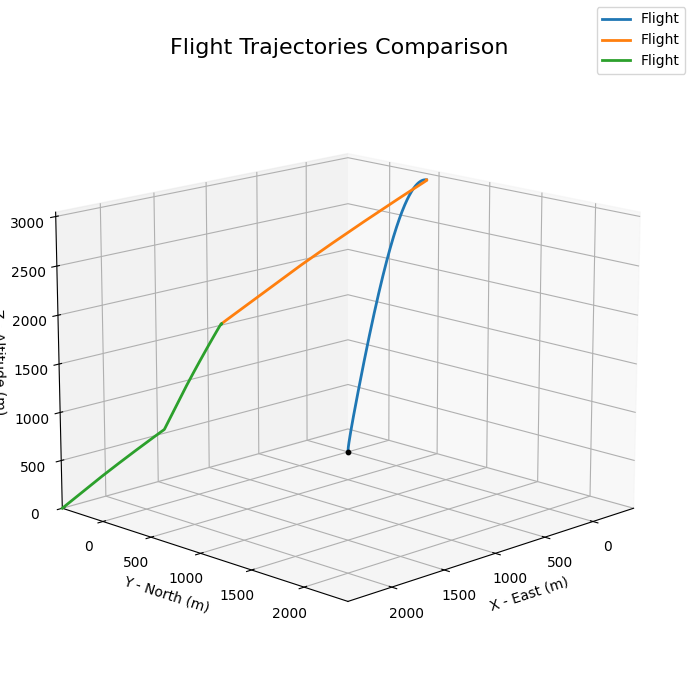

In [9]:
comparison = CompareFlights(
    [
        flights_by_name["first_stage"],
        flights_by_name["second_stage"],
        flights_by_name["payload"],
    ]
)

comparison.trajectories_3d(legend=True)

## 10) `FlightBody` is not yet supported for Flight execution

`FlightBody` is a lightweight value object satisfying the internal `BodyLike`
interface, useful for mission-level bookkeeping (e.g. `Mission.describe()`).
It does not yet implement everything `Flight` needs to integrate a real
trajectory (`total_mass()`, `add_motor()`, ...), so `MissionExecutor` raises a
clear error instead of silently producing an incorrect or empty flight if a
bare `FlightBody` is used as a mission item's body. This is a deliberate,
temporary limitation – see the mission-architecture roadmap for planned
`Flight`/`FlightBranch` integration for `FlightBody`.


In [10]:
demo_body = FlightBody(
    name="Unsupported Demo Body",
    geometry=0.05,
    mass_model=lambda t: 1.0,
    inertia_model=lambda t: (0.01, 0.01, 0.001, 0.0, 0.0, 0.0),
    center_of_mass_model=lambda t: 0.0,
)
demo_mission = Mission(name="FlightBody Guard Demo")
demo_mission.add_deployable(
    Deployable(
        name="unsupported_payload",
        body=demo_body,
        attachment=Attachment(
            parent_frame_position=[0.0, 0.0, 0.0],
            child_frame_position=[0.0, 0.0, 0.0],
        ),
        deployment_event=DeploymentEvent(
            name="Demo Deployment", trigger=lambda **kwargs: False
        ),
    )
)
demo_executor = MissionExecutor(mission=demo_mission, environment=env, rail_length=5.2)

try:
    demo_executor.execute()
except TypeError as error:
    print(f"Got expected error: {error}")

Got expected error: Cannot build a Flight from FlightBody 'Unsupported Demo Body': FlightBody does not implement total_mass()/add_motor() and cannot drive Flight's physics engine directly yet. Use a Rocket (optionally wrapped in RocketAdapter) for real flight execution; FlightBody-driven Flight integration is planned future work.
